In [1]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector, SetDensityMatrix
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from scipy.optimize import curve_fit

# Graphing Settings

In [3]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Importing Data

In [5]:
data1 = np.load("depolarizing_error_rates.npz")
data2 = np.load("convergence_axis_error_rates.npz")

rounds_arr1 = data1["rounds_arr"]
output_error_rate1 = data1["output_error_rate"]
simulation_round_threshold1 = data1["simulation_round_threshold"]
theoretical_round_threshold1 = data1["theoretical_round_threshold"]
simulation_output_error_rate_threshold1 = data1["simulation_output_error_rate_threshold"]
theoretical_output_error_rate_threshold1 = data1["theoretical_output_error_rate_threshold"]

rounds_arr2 = data2["rounds_arr"]
output_error_rate2 = data2["output_error_rate"]
simulation_round_threshold2 = data2["simulation_round_threshold"]
theoretical_round_threshold2 = data2["theoretical_round_threshold"]
simulation_output_error_rate_threshold2 = data2["simulation_output_error_rate_threshold"]
theoretical_output_error_rate_threshold2 = data2["theoretical_output_error_rate_threshold"]

# Plots

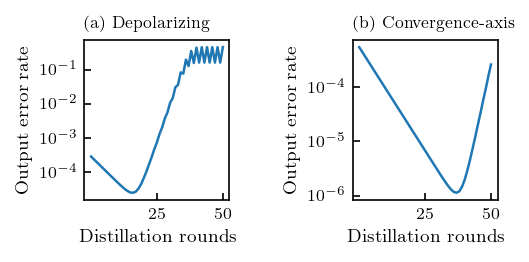

In [15]:
column_width = 3.4

fig, axes = plt.subplots(
    1, 2,
    figsize=(column_width, 1.75),
    sharex=False,
    sharey=False
)

# ── Plot 1: depolarizing noise ───────────────────────────
ax = axes[0]

ax.plot(
    rounds_arr1,
    output_error_rate1
)

ax.set_yscale("log")
ax.set_xlabel("Distillation rounds")
ax.set_ylabel("Output error rate")
ax.set_title(r"(a) Depolarizing", loc="left", fontsize=8)

# No top/right ticks
ax.tick_params(which='both', direction='in', top=False, right=False)

ax.set_xticks([25, 50])
ax.set_xticklabels([r'$25$', r'$50$'])
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())


# ── Plot 2: convergence-axis noise ───────────────────────
ax = axes[1]

ax.plot(
    rounds_arr2,
    output_error_rate2
)

ax.set_yscale("log")
ax.set_xlabel("Distillation rounds")
ax.set_ylabel("Output error rate")
ax.set_title(r"(b) Convergence-axis", loc="left", fontsize=8)

# No top/right ticks
ax.tick_params(which='both', direction='in', top=False, right=False)

ax.set_xticks([25, 50])
ax.set_xticklabels([r'$25$', r'$50$'])
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

# Compact single-column APS-style spacing
fig.subplots_adjust(
    left=0.17,
    right=0.98,
    bottom=0.27,
    top=0.88,
    wspace=0.85
)

plt.show()

In [14]:
print("(a):")
print(f"simulation_round_threshold = {simulation_round_threshold1}")
print(f"theoretical_round_threshold = {theoretical_round_threshold1}")
print(f"simulation_output_error_rate_threshold = {simulation_output_error_rate_threshold1}")
print(f"theoretical_output_error_rate_threshold = {theoretical_output_error_rate_threshold1}")
print("")

print("(b):")
print(f"simulation_round_threshold = {simulation_round_threshold2}")
print(f"theoretical_round_threshold = {theoretical_round_threshold2}")
print(f"simulation_output_error_rate_threshold = {simulation_output_error_rate_threshold2}")
print(f"theoretical_output_error_rate_threshold = {theoretical_output_error_rate_threshold2}")

(a):
simulation_round_threshold = 16
theoretical_round_threshold = 14.869772215800442
simulation_output_error_rate_threshold = 2.4190276921354226e-05
theoretical_output_error_rate_threshold = 2.0688192986017347e-05

(b):
simulation_round_threshold = 37
theoretical_round_threshold = 34.64636043311555
simulation_output_error_rate_threshold = 1.1321567163768975e-06
theoretical_output_error_rate_threshold = 1.2375376237304897e-06
